In [47]:
%pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [48]:
L = 40
T0, Tf = 5.0, 0.01
ANN_STEPS = 2000

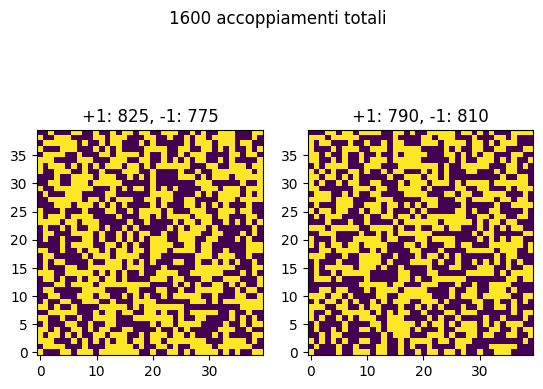

In [49]:
rng = np.random.default_rng(seed=75)
j_ver = rng.choice([-1,1], size=(L,L))
j_hor = rng.choice([-1,1], size=(L,L))
j_ver_up = 0
j_hor_up = 0
for i in range(L):
    for j in range(L):
        if j_ver[i,j] == 1:
            j_ver_up += 1

for i in range(L):
    for j in range(L):
        if j_hor[i,j] == 1:
            j_hor_up += 1

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(j_ver, origin="lower")
ax1.set_title(f"+1: {j_ver_up}, -1: {L**2 - j_ver_up}")
ax2.imshow(j_hor, origin="lower")
ax2.set_title(f"+1: {j_hor_up}, -1: {L**2 - j_hor_up}")
plt.suptitle(f"{L**2} accoppiamenti totali")
plt.show()

In [117]:
def greedy_mc(lattice, checkerboard, j_ver, j_hor, T=0.0):
    kb = 1.0
    for s in [checkerboard, ~checkerboard]:
        neig_j_sum = (
            np.roll(lattice, shift=1, axis=0) * np.roll(j_ver, shift=1, axis=0)
            + np.roll(lattice, shift=-1, axis=0) * j_ver
            + np.roll(lattice, shift=1, axis=1) * np.roll(j_hor, shift=1, axis=1)
            + np.roll(lattice, shift=-1, axis=1) * j_hor
        )
        de_s = 2 * lattice[s] * neig_j_sum[s]
        accept = de_s <= 0
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

def metropolis(lattice, even_mask, j_ver, j_hor, T=0.5):
    kb = 1.0
    for s in [even_mask, ~even_mask]:
        neig_j_sum = (
            np.roll(lattice, shift=1, axis=0) * np.roll(j_ver, shift=1, axis=0)
            + np.roll(lattice, shift=-1, axis=0) * j_ver
            + np.roll(lattice, shift=1, axis=1) * np.roll(j_hor, shift=1, axis=1)
            + np.roll(lattice, shift=-1, axis=1) * j_hor
        )
        de_s = 2 * lattice[s] * neig_j_sum[s]
        prob = np.exp(-de_s/(kb*T))
        accept = (de_s <= 0) | (rng.random(de_s.shape) < prob)
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

In [51]:
def energia(lattice, j_ver, j_hor):
    neig_j_sum = (
        np.roll(lattice, shift=-1, axis=0) * j_ver
        + np.roll(lattice, shift=-1, axis=1) * j_hor
    )
    tot_en = -np.sum(lattice * neig_j_sum)
    
    return tot_en

def magnetization(lattice):
    return np.abs(np.sum(lattice))

In [147]:
run = 10
spin_energies = np.zeros(run)
spin_magns = np.zeros(run)

for i in range(run):
    lattice = np.random.choice([-1,1], size=(L, L))
    checkerboard = np.zeros((L,L), dtype=bool)
    checkerboard[::2, ::2] = True
    checkerboard[1::2, 1::2] = True
    for _ in range(ANN_STEPS):
        greedy_mc(lattice, checkerboard, j_ver, j_hor)
    
    spin_energies[i] = energia(lattice, j_ver, j_hor) / L**2
    spin_magns[i] = magnetization(lattice) / L**2

spin_errs = np.std(spin_energies, ddof=1) / np.sqrt(run)

In [65]:
print(f"Energia media: {np.mean(spin_energies)}")
print(f"Std.dev.: +-{np.std(spin_energies, ddof=1) / np.sqrt(run)}")
print(f"Energia minima: {np.min(spin_energies)}")
print(f"Energia massima: {np.max(spin_energies)}")
print(f"Magnetizzazione media: {np.mean(spin_magns)}")

Energia media: -1.366
Std.dev.: +-0.002280655363900668
Energia minima: -1.37625
Energia massima: -1.35375
Magnetizzazione media: 0.015375


In [146]:
run = 10
energies_metro = np.zeros(run)
magns_metro = np.zeros(run)

for i in range(run):
    lattice = np.random.choice([-1,1], size=(L, L))
    checkerboard = np.zeros((L,L), dtype=bool)
    checkerboard[::2, ::2] = True
    checkerboard[1::2, 1::2] = True
    for _ in range(ANN_STEPS):
        metropolis(lattice, checkerboard, j_ver, j_hor)
    
    energies_metro[i] = energia(lattice, j_ver, j_hor) / L**2
    magns_metro[i] = magnetization(lattice) / L**2

metro_errs = np.std(energies_metro, ddof=1) / np.sqrt(run)

In [64]:
print(f"Energia media: {np.mean(energies_metro)}")
print(rf"$\sigma$: +-{np.std(energies_metro, ddof=1) / np.sqrt(run)}")
print(f"Energia minima: {np.min(energies_metro)}")
print(f"Energia massima: {np.max(energies_metro)}")
print(f"Magnetizzazione media: {np.mean(magns_metro)}")

Energia media: -1.37325
$\sigma$: +-0.0014813657362192654
Energia minima: -1.38125
Energia massima: -1.36625
Magnetizzazione media: 0.01225


||Greedy (T=0)|Metropolis (T=0.5)|
|---|---|---|
|En. max|-1.35|-1.37|
|En. min|-1.38|-1.38|
|En. media|-1.37|-1.37|
|$\sigma$|$\pm$0.002|$\pm$0.001|
|Magn. media|0.02|0.01|

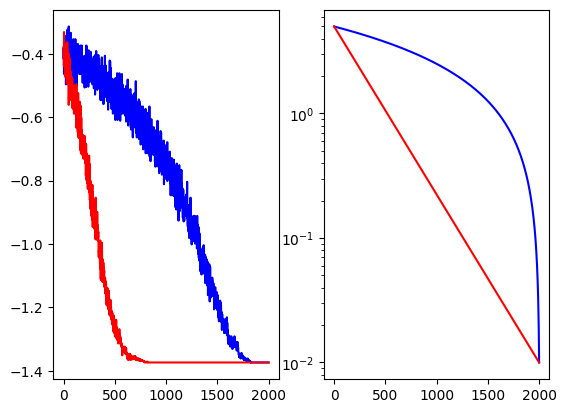

In [113]:
lin_annealing = np.linspace(T0, Tf, ANN_STEPS)
exp_annealing = np.logspace(np.log10(T0), np.log10(Tf), ANN_STEPS)
lin_ann_en = np.zeros(ANN_STEPS)
exp_ann_en = np.zeros(ANN_STEPS)
lin_lattice = np.random.choice([-1,1], size=(L, L))
exp_lattice = np.random.choice([-1,1], size=(L, L))
checkerboard = np.zeros((L,L), dtype=bool)
checkerboard[::2, ::2] = True
checkerboard[1::2, 1::2] = True
for i in range(ANN_STEPS):
    metropolis(lin_lattice, checkerboard, j_ver, j_hor, T=lin_annealing[i])
    metropolis(exp_lattice, checkerboard, j_ver, j_hor, T=exp_annealing[i])
    lin_ann_en[i] = energia(lin_lattice, j_ver, j_hor) / L**2
    exp_ann_en[i] = energia(exp_lattice, j_ver, j_hor) / L**2

lin_color, exp_color = "blue", "red"
fig, (en, temp) = plt.subplots(1, 2)
en.plot(lin_ann_en, color=lin_color)
en.plot(exp_ann_en, color=exp_color)
temp.plot(lin_annealing, color=lin_color)
temp.plot(exp_annealing, color=exp_color)
temp.set_yscale("log")
plt.show()

In [143]:
run = 10
ANN_STEPS = 2000
lin_annealing = np.linspace(T0, Tf, ANN_STEPS)
exp_annealing = np.logspace(np.log10(T0), np.log10(Tf), ANN_STEPS)
lin_ann_en = np.zeros(run)
exp_ann_en = np.zeros(run)

checkerboard = np.zeros((L,L), dtype=bool)
checkerboard[::2, ::2] = True
checkerboard[1::2, 1::2] = True

for i in range(run):
    lin_lattice = np.random.choice([-1,1], size=(L, L))
    exp_lattice = np.random.choice([-1,1], size=(L, L))
    for j in range(ANN_STEPS):
        metropolis(lin_lattice, checkerboard, j_ver, j_hor, T=lin_annealing[j])
        metropolis(exp_lattice, checkerboard, j_ver, j_hor, T=exp_annealing[j])
    lin_ann_en[i] = energia(lin_lattice, j_ver, j_hor) / L**2
    exp_ann_en[i] = energia(exp_lattice, j_ver, j_hor) / L**2

lin_errs = np.std(lin_ann_en, ddof=1) / np.sqrt(run)
exp_errs = np.std(exp_ann_en, ddof=1) / np.sqrt(run)

In [115]:
print(f"Media energia: LINEARE={np.mean(lin_ann_en)}, EXP={np.mean(exp_ann_en)}")
print(f"Std.dev: LINEARE={np.std(lin_ann_en, ddof=1) / np.sqrt(run)}, EXP={np.std(exp_ann_en, ddof=1) / np.sqrt(run)}")

Media energia: LINEARE=-1.3775, EXP=-1.3789999999999998
Std.dev: LINEARE=0.0015920810978785772, EXP=0.0012047360245667543


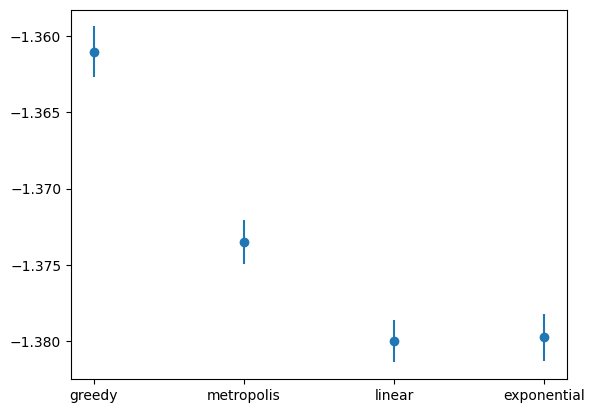

In [148]:
mean_engs = [np.mean(spin_energies), np.mean(energies_metro), np.mean(lin_ann_en), np.mean(exp_ann_en)]
labels = ["greedy", "metropolis", "linear", "exponential"]
errs = [spin_errs, metro_errs, lin_errs, exp_errs]
plt.errorbar(labels, mean_engs, yerr=errs, fmt="o")
plt.show()